In [1]:
#### mv packages ####
import modules.data as d
import modules.model as m
import modules.pooling as p
import modules.train as t
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device()#['cuda:1', 'cuda:0'])
# device, generator = u.Devices().set_device('cpu')

#### data ####
brca = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=False, 
    log_transform=False,
    scale_method=None,

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
_dataset = d.GraphDataset(brca)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:7

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:7)
# edge_index               (2, 32798)               Tensor (cuda:7)
# edge_attr                (32798, 16)              Tensor (cuda:7)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:7)
# x                        (562, 4383, 1)           Tensor (cuda:7)
# y                        (562,)                   Tensor (cuda:7)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


In [2]:
#### convenience variables ####
_embedding_size = 16

# from mask (init)
_mask = brca.mask
_num_nodes, _num_sets = _mask.shape

# from batch (forward)
_batch_size = int(_batch.x.shape[0]/_num_nodes)
_num_node_features = _batch.x.shape[1] # or brca.num_node_features
_x = _batch.x.view(_batch.batch_size, int(_batch.x.shape[0]/_batch.batch_size), -1)

---

In [3]:
from modules.utils import reshape, filter_kwargs
from modules.model import cloneable, get_layers, attn_dims

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn import MessagePassing, GCNConv, GATConv

from torch import Tensor
from torch_geometric.data import Batch, Data # Batch is a subclass of Data
from typing import Literal, Optional, Union

In [4]:
def input_to_dict(input):
    if isinstance(input, Tensor): # x (Tensor) only
        data = {'x':input}
    elif isinstance(input, Data): # PyG Data or DataBatch
        data = {key: getattr(input, key) for key in input.keys()}
    elif isinstance(input, dict): # predefined dict
        data = input
    else:
        raise TypeError(f'unsupported input type: {type(input)}')
    return data

In [5]:
@cloneable
class Sequential(nn.Module):
    def __init__(
        self,
        in_channels:int, 
        out_channels:int, 
        layer_class:nn.Module, 
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,
        layer_kwargs:dict={},
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.layers = get_layers(
            in_channels,
            out_channels,
            layer_class,
            hidden_dims,
            act_fn,
            norm_fn,
            end_fn,
            layer_kwargs
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # get input as kwargs dict
        data = input_to_dict(input)

        # extract x as positional, update kwargs if provided
        x = data['x']
        data = {k:v for k,v in data.items() if k!='x'}
        data.update(kwargs)

        out = {}

        # forward pass through layers
        for layer in range(len(self.layers)):
            layer_out = filter_kwargs(self.layers[layer])(x, **data)

            # filter output if tuple
            if isinstance(layer_out, torch.Tensor):
                x = layer_out
                
            elif isinstance(layer_out, tuple):
                x = layer_out[0]
                remaining = layer_out[1:]

                if len(remaining) == 1: 
                    out[f'out_{layer}'] = remaining[0] # unpacks tuple if 1
                else:
                    out[f'out_{layer}'] = remaining # keeps tuple if 2+

            else:
                raise TypeError(f'unsupported layer output type: {type(layer_out)}')
            
        if return_dict:
            out['x'] = x
            return out
        else:
            return x

In [6]:
@cloneable
class SetPooling(nn.Module):
    @filter_kwargs
    def __init__(self, mask:Tensor, num_features:int, *args, **kwargs):
        '''
        mask: (nodes, sets)
        should adapt to have edge features in future
        '''
        super().__init__()
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.num_features = num_features

    def forward(self, input:Union[Data, Tensor, dict], concat:bool=True, return_dict:bool=False):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, nodes, features)
        x_node = reshape(x=data['x'], to='b,n,f', num_nodes=self.num_nodes, num_features=self.num_features)

        # pool x to (batch, set, features)
        x_set = self.pool(x_node)

        # concat to (batch, nodes + sets, features)
        x = torch.cat([x_node, x_set], dim=1) if concat else x_set

        return {'x':x} if return_dict else x

    def pool(self, x:Tensor):
        '''
        define in child class. default: mean
        '''
        # sum across sets (add pool)
        x_set = torch.einsum('bnf,ns->bsf', x, self.mask)

        # nodes per set (denom); clamp for sum=0 case
        nodes_per_set = self.mask.sum(dim=0).clamp(min=1).view(1,self.num_sets,1)

        # return mean (sum per set/total per set)
        return x_set / nodes_per_set

In [7]:
@cloneable
class AttentionSetPooling(SetPooling):
    def __init__(
        self, 
        mask:Tensor, 
        num_features:int,

        # lin 
        hidden_dims:list[int]=None,
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        *args, **kwargs
    ):
        super().__init__(mask, num_features, *args, **kwargs)

        self.lin = Sequential(
            in_channels=num_features,
            out_channels=self.num_sets,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def pool(self, x:Tensor):
        # compute masked scores, attention
        scores = self.lin(x).masked_fill(self.mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)

        # apply attention (weighted mean)
        x = torch.einsum('bnf,bns->bsf', x, attn)

        return x


---

In [8]:
@cloneable
class Encoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers; instance or predefined
        node_encoder:Union[nn.Module,Sequential]=None,
        set_pooling:SetPooling=None,

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node',
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        # dims
        self.mask = mask
        self.num_features = num_features
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method

        # node encoder; init new, or copy if provided
        if isinstance(node_encoder, type) and issubclass(node_encoder, nn.Module):
            self.node_encoder = Sequential(
                in_channels=self.num_features,
                out_channels=self.embed_dim,
                layer_class=node_encoder,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(node_encoder,(nn.Module, Sequential)):
            self.node_encoder = node_encoder.copy()
        else:
            raise TypeError(f'node_encoder must be a type, predefined nn.Module, or Sequential, got: {type(node_encoder)}')

        # set pooling
        if isinstance(set_pooling, type) and issubclass(set_pooling, SetPooling):
            self.set_pooling = set_pooling(
                mask=self.mask,
                num_features=self.embed_dim,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(set_pooling, (nn.Module, SetPooling)):
            self.set_pooling = set_pooling.copy()
        else:
            self.set_pooling = None

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=False, **kwargs):
        # node embedding
        h = self.node_encoder(input, return_dict=return_dict, **kwargs)
        h = input_to_dict(h) # extract if dict
        x = reshape(h['x'], 'b,n,f', num_nodes=self.num_nodes, num_features=self.embed_dim)

        if self.method == 'set':
            assert self.set_pooling is not None, "set_pooling must be provided for method='set'"
            x = self.set_pooling(x, concat=False)

        elif self.method == 'twin':
            assert self.set_pooling is not None, "set_pooling must be provided for method='twin'"
            x = self.set_pooling(x, concat=True)

        if return_dict:
            h['x'] = x
            return h
        else:
            return x

In [9]:
@cloneable
class Latent(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # mlp
        mlp:Union[bool,Sequential]=False,
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # pooling
        global_pooling:SetPooling=None,
        method:Literal['node','set','twin']='node',
        fwd:Literal['node','set','twin','twin_pool']=None,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)

        # dims
        self.mask = mask
        self.num_nodes, self.num_sets = mask.shape
        self.embed_dim, self.head_dim, self.num_heads = attn_dims(embed_dim, head_dim, num_heads)
        self.method = method
        
        # default fwd
        if fwd == None:
            fwd = method
        self.fwd = fwd

        # determine n dim (for reshaping)
        num_nodes, num_sets = mask.shape
        if method == 'node':
            self.n_dim = num_nodes
            self.split_dim = None
        elif method == 'set':
            self.n_dim = num_sets
            self.split_dim = None
        elif method == 'twin':
            self.n_dim = num_nodes + num_sets
            self.split_dim = [num_nodes, num_sets]
        else:
            raise TypeError(f'unsupported method: {method}')
        
        # mlp
        if mlp:
            self.mlp = Sequential(
                in_channels=self.embed_dim,
                out_channels=self.embed_dim,
                layer_class=nn.Linear,
                hidden_dims=hidden_dims,
                act_fn=act_fn,
                norm_fn=norm_fn,
                end_fn=end_fn
            )
        elif isinstance(mlp, (nn.Module, Sequential)):
            self.mlp = mlp.clone()
        else:
            self.mlp = None

        # pooling
        def init_pooling(pooling, mask, condition):
            if condition:
                if isinstance(pooling, type) and issubclass(pooling, SetPooling):
                    return pooling(
                        mask=mask,
                        num_features=self.embed_dim,
                        hidden_dims=hidden_dims,
                        act_fn=act_fn,
                        norm_fn=norm_fn,
                        end_fn=end_fn
                    )
                elif isinstance(pooling, (nn.Module, SetPooling)):
                    return pooling.copy(mask=mask)
                else:
                    raise TypeError(f'global_pooling must be a type, predefined nn.Module, or SetPooling, got: {type(global_pooling)}')
            else:
                return None

        self.node_pool = init_pooling(global_pooling, torch.ones(self.num_nodes,1), method in ('node','twin'))
        self.set_pool = init_pooling(global_pooling, torch.ones(self.num_sets,1), method in ('set','twin'))
        self.twin_pool = init_pooling(global_pooling, torch.ones(2,1), fwd == 'twin_pool')

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        # get x in (batch, n, features), where n is (nodes) or (nodes+sets)
        x = reshape(x=data['x'], to='b,n,f', num_nodes=self.n_dim, num_features=self.embed_dim)

        # mlp
        x = self.mlp(x) if self.mlp is not None else x

        # pool
        if self.method == 'node':
            z_node = self.node_pool(x, concat=False)
            z_set = None
        elif self.method == 'set':
            z_node = None
            z_set = self.set_pool(x, concat=False)
        else: #self.method == 'twin'
            x_node, x_set = x.split(self.split_dim, dim=1) #split, pool sep
            z_node = self.node_pool(x_node, concat=False)
            z_set = self.set_pool(x_set, concat=False)

        # fwd
        if self.fwd == 'node':
            x = z_node
        elif self.fwd == 'set':
            x = z_set
        else: # self.fwd == 'twin' or 'twin_pool':
            x = torch.cat([z_node, z_set], dim=1)
            x = self.twin_pool(x, concat=False) if self.fwd == 'twin_pool' else x.mean(dim=1)

        # squeeze to (b,F)
        x = x.squeeze(1)
        z_node = z_node.squeeze(1) if z_node is not None else z_node
        z_set = z_set.squeeze(1) if z_set is not None else z_set

        # return
        return {'x':x, 'z_node':z_node, 'z_set':z_set} if return_dict else (x, z_node, z_set)


In [10]:
@cloneable
class GlobalNodeDecoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layer args
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # decoder
        expand_mlp:bool=False,
        shared_mlp:bool=True,
        fit_nb:bool=False,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        # dims
        self.num_nodes, _ = mask.shape
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # global node embedding
        self.node_embed = nn.Parameter(torch.randn(self.num_nodes, embed_dim))

        # node + sample estimate
        self.estimate = Sequential(
            in_channels=embed_dim,
            out_channels=1,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

        self.bias = Sequential(
            in_channels=embed_dim,
            out_channels=1,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get inputs as kwargs dict
        data = input_to_dict(input)
        z = data['x']
        batch_size = z.shape[0]

        # Expand sample embedding per node
        z = z.unsqueeze(1).expand(-1, self.num_nodes, -1)     # (batch, num_nodes, latent_dim)
        nodes = self.node_embed.unsqueeze(0).expand(batch_size, -1, -1)  # (batch, num_nodes, node_embed_dim)

        # decoder_input = torch.cat([z, nodes], dim=-1)           # (batch, num_nodes, latent + node_embed)
        mu = self.estimate(nodes)                        # -> (batch, num_nodes, 1)
        mu = torch.exp(mu).view(-1,1)

        beta = self.bias(z)
        beta = torch.exp(beta).view(-1,1)

        x_recon = mu * beta

        return x_recon






In [11]:
@cloneable
class GlobalNBDecoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layer args
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # decoder
        expand_mlp:bool=False,
        shared_mlp:bool=True,
        fit_nb:bool=False,
        *args, **kwargs
    ):
        super().__init__(*args, **kwargs)
        # dims
        self.num_nodes, _ = mask.shape
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # node + sample estimate
        self.expand = Sequential(
            in_channels=embed_dim,
            out_channels=self.num_nodes * embed_dim,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

        self.bias = Sequential(
            in_channels=embed_dim,
            out_channels=1,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            norm_fn=norm_fn,
            end_fn=end_fn
        )

        self.mu = nn.Parameter(torch.randn(self.num_nodes, 1))
        self.theta = nn.Parameter(torch.randn(self.num_nodes, 1))

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get inputs as kwargs dict
        data = input_to_dict(input)
        z = data['x']
        batch_size = z.shape[0]

        # expand z (b,E) -> (b,n,E)
        z = self.expand(z)
        z = z.view(batch_size, self.num_nodes, -1)
        
        # estimate bias -> (b,n,1)
        bias = self.bias(z)

        # #### direct ####
        # x_recon = torch.exp(bias).view(-1,1)

        # if return_dict:
        #     return {'x_recon':x_recon, 'mu':None, 'theta':None}
        # else:
        #     return x_recon, None, None

        ### NB ####

        # expand mu, theta to match bias (1,n,1) -> (b,n,1)
        mu = self.mu.unsqueeze(0).expand(bias.shape)
        theta = self.theta.unsqueeze(0).expand(bias.shape)

        # reshape to match original input for loss computation (b*n,1)
        bias = torch.exp(bias).view(-1,1)
        mu = torch.exp(mu).reshape(-1,1)
        theta = torch.exp(theta).reshape(-1,1)

        # get pred
        x_recon = mu * bias
        
        if return_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta}
        else:
            return x_recon, mu, theta


In [12]:
@cloneable
class Autoencoder(nn.Module):
    def __init__(
        self,
        # dims
        mask:Tensor=None,
        num_features:int=None, # encoder
        embed_dim:int=None,
        head_dim:int=None,
        num_heads:int=1,

        # layers
        node_encoder:Union[nn.Module,Sequential]=None, # encoder
        pooling:SetPooling=None, # encoder (set), latent (global)
        mlp:Union[bool,Sequential]=False, # latent

        # layer params
        hidden_dims:list[int]=None, 
        act_fn:nn.Module=None, 
        norm_fn:Literal['batch','layer']=None, 
        end_fn:Union[bool,nn.Module]=False,

        # etc
        method:Literal['node','set','twin']='node', # encoder, latent
        fwd:Literal['node','set','twin','twin_pool']=None, # latent
        expand_mlp:bool=False, # decoder
        shared_mlp:bool=True, # decoder
        fit_nb:bool=False, # decoder
        log_transform:bool=True # autoencoder
    ):
        super().__init__()
        self.log_transform = log_transform

        # dims
        embed_dim, head_dim, num_heads = attn_dims(embed_dim, head_dim, num_heads)

        # modules
        self.encoder = Encoder(
            mask, num_features, embed_dim, head_dim, num_heads,
            node_encoder, pooling,
            hidden_dims, act_fn, norm_fn, end_fn,
            method
        )

        self.latent = Latent(
            mask, embed_dim, head_dim, num_heads,
            mlp,
            hidden_dims, act_fn, norm_fn, end_fn,
            pooling, method, fwd
        )

        self.decoder = GlobalNBDecoder(
            mask, embed_dim, head_dim, num_heads,
            hidden_dims, act_fn, norm_fn, end_fn,
            expand_mlp, shared_mlp, fit_nb
        )

    def forward(self, input:Union[Data, Tensor, dict], return_dict:bool=True):
        # get input as kwargs dict
        data = input_to_dict(input)

        if self.log_transform:
            data['x'] = torch.log1p(data['x'])

        # return tensor h (h_n, h_s, or h_ns)
        h = self.encoder(data, return_dict=False) # return_attention_weights=None

        # get z
        z, z_node, z_set = self.latent(h, return_dict=False)

        # get recon
        x_recon, mu, theta = self.decoder(z, return_dict=False)

        if return_dict:
            return {'x_recon':x_recon, 'mu':mu, 'theta':theta}
        else:
            return x_recon, mu, theta

In [13]:
ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features,
    embed_dim=16,
    num_heads=2,
    node_encoder=GATConv,
    pooling=AttentionSetPooling,
    mlp=True,
    norm_fn='layer',
    fit_nb=False,
    method='node'
)

out = ae(_batch, return_dict=True)
print(out['x_recon'].shape)

torch.Size([280512, 1])


In [14]:
from modules.train import Loader, Trainer
from torchmetrics.functional import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

class Log2ReconTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        data = input_to_dict(batch)
        x = data.get('x')
        x = torch.log2(x+1)

        # forward pass
        out = self.model(batch)
        x_recon = out.get('x_recon')
        x_recon = torch.log2(x_recon+1)

        # compute loss
        loss = self.loss_fn(x, x_recon)

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([batch['x'] for batch in batch_log['batch']])
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']])
        # mu = torch.cat([batch['mu'] for batch in batch_log['out']])
        # theta = torch.cat([batch['theta'] for batch in batch_log['out']])

        # scale outputs to log2        
        log2_x = torch.log2(x + 1)
        log2_x_recon = torch.log2(x_recon + 1)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            # 'mu': mu.cpu().numpy(),
            # 'theta': theta.cpu().numpy(),
        }

        return metrics, values

In [15]:
from modules.train import NBLoss

class UncertaintyLoss(nn.Module):
    def __init__(self, num_tasks: int):
        super().__init__()
        # log(sigma^2) per task, initialized to 0 (i.e., sigma = 1)
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, losses:list):
        """
        losses: Tensor of shape (num_tasks,) or (batch_size, num_tasks)
        """
        losses = torch.stack(losses)
        precision = torch.exp(-self.log_vars)            # (num_tasks,)
        weighted = precision * losses                    # (num_tasks,) or (batch_size, num_tasks)
        reg = self.log_vars                              # (num_tasks,)
        return (weighted + reg).sum(dim=-1).mean()       # sum over tasks, mean over batch if needed


class NBReconTrainer(Trainer):
    def _compute_loss(self, batch):
        # extract x
        data = input_to_dict(batch)
        x = data.get('x')
        log2_x = torch.log2(x+1)

        # forward pass
        out = self.model(batch)
        x_recon = out.get('x_recon')
        log2_x_recon = torch.log2(x_recon+1)
        mu = out.get('mu')
        theta = out.get('theta')

        # compute loss
        recon_loss = self.loss_fn(log2_x, log2_x_recon)
        nb_loss = torch.log1p(NBLoss()(x, mu, theta))
        
        criterion = UncertaintyLoss(num_tasks=2)
        loss = criterion([recon_loss,nb_loss])
        # loss = recon_loss

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute loss
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        # get outputs
        x = torch.cat([batch['x'] for batch in batch_log['batch']])
        x_recon = torch.cat([batch['x_recon'] for batch in batch_log['out']])
        mu = torch.cat([batch['mu'] for batch in batch_log['out']])
        theta = torch.cat([batch['theta'] for batch in batch_log['out']])

        # scale outputs to log2        
        log2_x = torch.log2(x + 1)
        log2_x_recon = torch.log2(x_recon + 1)
        log2fc = log2_x_recon - log2_x
        mse = mean_squared_error(log2_x_recon, log2_x)

        # compute log2 metrics
        metrics['mean'] = torch.mean(log2fc).item()
        metrics['std'] = torch.std(log2fc).item()
        metrics['mae'] = mean_absolute_error(log2_x_recon, log2_x).item()
        metrics['mse'] = mse.item()
        metrics['rmse'] = torch.sqrt(mse).item()
        metrics['r2'] = r2_score(log2_x_recon, log2_x).item()

        # convert values to numpy
        values = {
            'x': x.cpu().numpy(),
            'x_recon': x_recon.cpu().numpy(),
            'mu': mu.cpu().numpy(),
            'theta': theta.cpu().numpy(),
        }

        return metrics, values

In [16]:
ae = Autoencoder(
    mask=brca.mask,
    num_features=brca.num_node_features, # encoder
    # embed_dim=None,
    head_dim=32,
    num_heads=10,

    # layers
    node_encoder=nn.Linear, # encoder
    pooling=AttentionSetPooling, # encoder (set), latent (global)
    mlp=True, # latent

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,

    # etc
    method='set', # encoder, latent
    fwd=None, # latent
    expand_mlp=True, # decoder
    shared_mlp=False, # decoder
    fit_nb=False, # decoder
    log_transform=True # autoencoder
)

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

trainer = NBReconTrainer(
    model=ae,
    loader=loader,
    num_epochs=150,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss','mae','rmse', 'r2'],
)

display(trainer.test_metrics)

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [01:41<00:00,  1.48it/s, Epoch 149     Train: loss=9.8437    mae=0.9329    rmse=1.3310    r2=0.7811        Val: loss=9.8447    mae=0.9337    rmse=1.3151    r2=0.7843]   

Test	 loss=9.7773    mae=0.9017    rmse=1.3048    r2=0.7836



{'loss': 9.77734661102295,
 'mean': 0.06711041182279587,
 'std': 1.3031071424484253,
 'mae': 0.9016822576522827,
 'mse': 1.7025874853134155,
 'rmse': 1.3048323392868042,
 'r2': 0.7835692167282104}

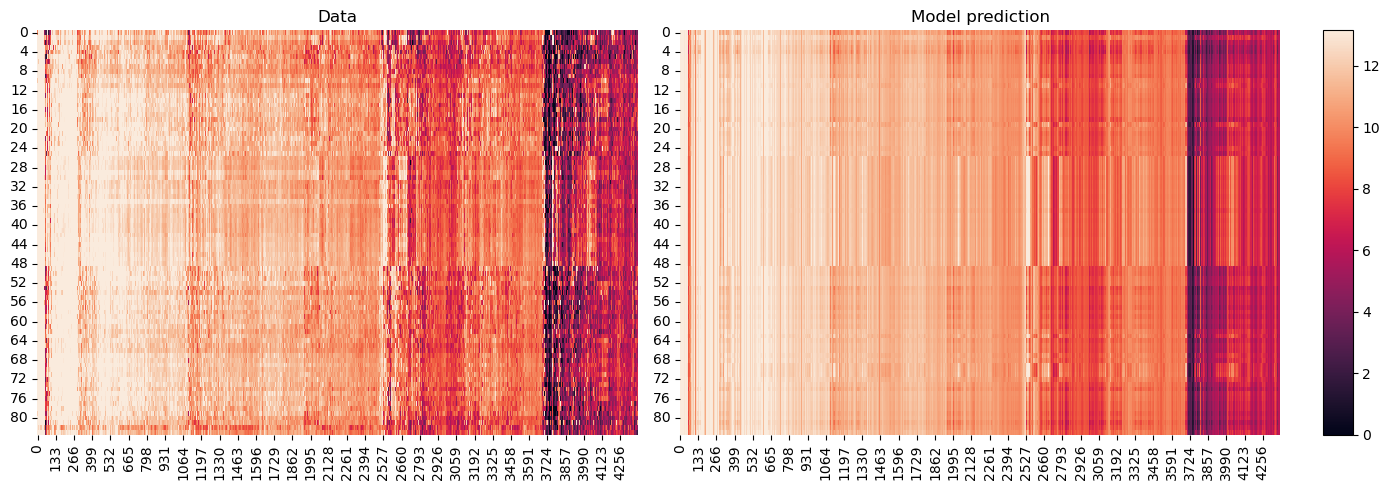

In [17]:
import numpy as np
import scipy.cluster.hierarchy as sch

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

x_in = np.log2(trainer.test_values['x'].reshape(-1,brca.num_nodes)+1)
x_out = np.log2(trainer.test_values['x_recon'].reshape(-1,brca.num_nodes)+1)

# Cluster rows
row_linkage = sch.linkage(x_in, method='average')
row_dendro = sch.dendrogram(row_linkage, no_plot=True)
row_order = row_dendro['leaves']

# Cluster columns
col_linkage = sch.linkage(x_in.T, method='average')
col_dendro = sch.dendrogram(col_linkage, no_plot=True)
col_order = col_dendro['leaves']

# Reorder
x_in = x_in[np.ix_(row_order, col_order)]
x_out = x_out[np.ix_(row_order, col_order)]

# Set up a gridspec layout: 1 row, 3 columns
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.05])

# Create subplots according to gridspec
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# Common color scale
vmin = 0
vmax = np.percentile(x_in, 90)

# Plot heatmaps
sns.heatmap(x_in, ax=ax0, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax0.set_title('Data')
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)

sns.heatmap(x_out, ax=ax1, vmin=vmin, vmax=vmax, cmap="rocket", cbar=False)
ax1.set_title('Model prediction')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Shared colorbar
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation='vertical')

plt.tight_layout()
plt.show()

<Axes: >

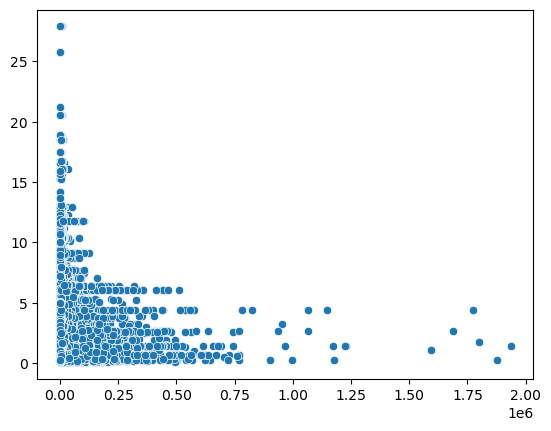

In [18]:
sns.scatterplot(
    x=trainer.test_values['x'].squeeze(-1),
    y=trainer.test_values['mu'].squeeze(-1)
)

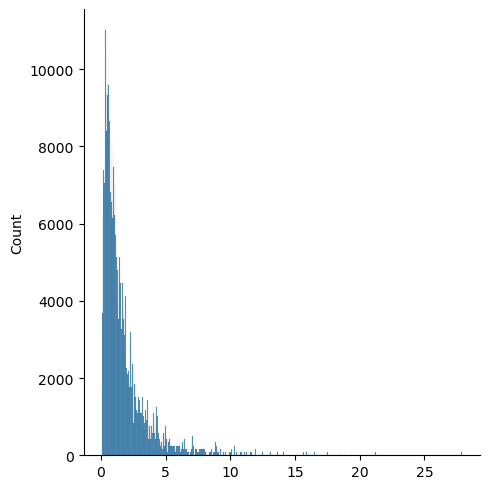

In [19]:
sns.displot(
    trainer.test_values['mu'].squeeze(-1)
)